In [1]:
from adabin import adap_bin

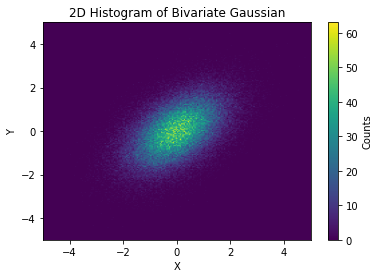

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define parameters of the bivariate Gaussian
mean = [0, 0]  # Center of the distribution
cov = [[1, 0.5], [0.5, 1]]  # Covariance matrix

# Step 2: Generate samples
num_samples = 100000
samples = np.random.multivariate_normal(mean, cov, size=num_samples)

# Step 3: Create a fine 2D histogram (binning)
num_bins = 200
x_edges = np.linspace(-5, 5, num_bins + 1)
y_edges = np.linspace(-5, 5, num_bins + 1)
hist, x_edges, y_edges = np.histogram2d(samples[:,0], samples[:,1], bins=[x_edges, y_edges])

# Step 4: Plot the result
plt.imshow(hist.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], aspect='auto', cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogram of Bivariate Gaussian')
plt.show()

In [3]:
hist

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [4]:
import numpy as np

In [6]:
np.sqrt(hist+1)

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [30]:
res_signal, res_noise, maps = adap_bin(hist, np.sqrt(hist)+1)

In [31]:
print(maps[100])
print(np.max(maps))
print(np.shape(maps))

[6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6.
 6. 6. 6. 6. 6. 6. 6. 6. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 3. 3. 3. 3. 3. 3. 3. 3. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 1. 1. 1. 1.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2.
 3. 3. 3. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4. 4. 6. 6. 6. 6. 6. 6. 6. 6.
 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6. 6.
 6. 6. 6. 6. 6. 6. 6. 6.]
7.0
(200, 200)


In [32]:
def _display_map(ax, signal, noise,
                log=True, vrange=(-3, 0), min_SN=3,
                cmap=plt.cm.RdYlBu_r, fontsize=20):
    img = np.flipud(np.where(signal / noise > min_SN, signal, np.nan))
    h, w = signal.shape
    
    if log:
        img = np.log10(img)

    if min_SN < 0.:
        im = ax.imshow(img, cmap=plt.cm.get_cmap('RdYlBu', int(np.ptp(img))))
    else:
        print("[display_map]: %d pixels with S/N > %d.\n" %(
              np.sum(signal / noise > min_SN), min_SN))
        im = ax.imshow(img, cmap=cmap, vmin=vrange[0], vmax=vrange[1])
    
    return im

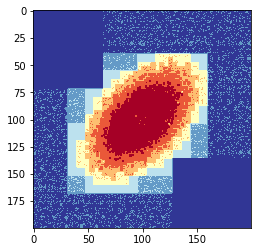

In [41]:
ax = plt.subplot()
im = _display_map(ax, maps, 1., min_SN=-1., log=False, cmap=plt.cm.RdYlBu)